In [12]:
import numpy as np
import matplotlib.pyplot as plt
import math

In [13]:
alpha=0.5
epsilon=0.1

In [14]:
#sarsa
Q=np.zeros((4,12,4))
number_episodes=500
rewards=np.zeros(number_episodes)
min_path=20000 # intial length of path
for n_episode in range(number_episodes):
    path_i=[]
    path_j=[]
    
    # initial state: starting (3,0)
    i=0
    j=0
    total_rewards=0
    # select the first action
    if np.random.random() < epsilon:
        A=np.random.randint(0,4)
        
    else:
        A=np.argmax(Q[i,j])
    #print('A=', A)
    #loop for each step of episode:
    #   take action A, observe R, S'
    #   choose A' from S' using e-greedy
    #   Q(S,A) <-- Q(S,A)+alpha*[R+rQ(S', A')-Q(S,A)]
    #   S <-- S', A <-- A'
    # until S is terminal
    time_step=0
    path_i.append(i)
    path_j.append(j)
    while True:
        if i==0 and j==11:
            rewards[n_episode]=total_rewards
            if time_step<min_path:
                min_path=time_step
                optimal_path_i=path_i
                optimal_path_j=path_j
            
            break
        # find R and the next state S' based on (i,j,A)
        R=-1
        #if i==0 and j==11:
        #    R=0
            
        # move right    
        if A==0:
            next_i=i
            temp_j=j+1
            if temp_j>11:
                next_j=11
            else:
                next_j=temp_j
             
                
        # move up    
        elif A==1:
            temp_i=i+1
            if temp_i<=3:
                next_i=temp_i
            else:
                next_i=3
            next_j=j
             
        # move left    
        elif A==2:
            next_i=i
            temp_j=j-1
            if temp_j<0:
                next_j=0
            else:
                next_j=temp_j  
              
        # move down    
        elif A==3:
            temp_i=i-1
            if temp_i<0:
                next_i=0
            else:
                next_i=temp_i
            next_j=j
            
        # if fall cliff,  return to start point with a reward -100
        if next_i==0 and (next_j<11 and next_j>0):
            next_i=0
            next_j=0  
            R=-100
        
        #choose A' from S' using e-greedy
        if np.random.random() < epsilon:
            next_A=np.random.randint(0,4)
        else:
            next_A=np.argmax(Q[int(next_i),int(next_j)])
            
        # sarsa
        Q[i,j,A]=Q[i,j,A]+alpha*(R+Q[int(next_i), int(next_j), next_A]-Q[i,j,A])
        
        # Q-learning
        # Q[i,j,A]=Q[i,j,A]+alpha*(R+max(Q[int(next_i),int(next_j)])-Q[i,j,A])
        
        #print(time_step, i,j, A, next_A)
        i=int(next_i)
        j=int(next_j)
        A=next_A
        time_step=time_step+1
        total_rewards=total_rewards+R
        path_i.append(i)
        path_j.append(j)
 

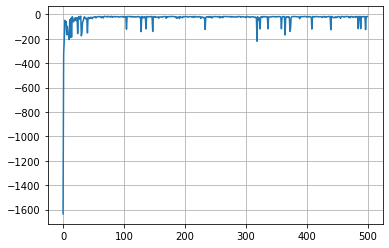

In [15]:
rewards_sarsa=rewards
plt.plot(rewards_sarsa)
# cost is the number of steps in an episode
plt.grid()

array([[[-121.66818884,  -19.61890994,  -36.02868952,  -46.18301682],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ]],

       [[ -62.88154447,  -18.29766404,  -20.09622468,  -22.19908088],
        [ -32.28305587,  -17.90700885,  -19.02670258, -111.71971588],
        [ -16.7383

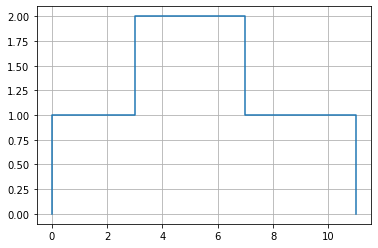

In [16]:
plt.plot(optimal_path_j, optimal_path_i)
plt.grid()
Q

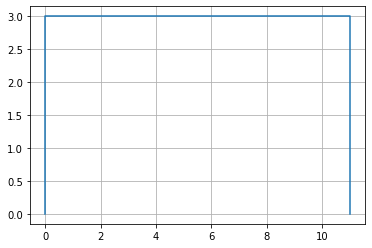

In [17]:
# From final Q[4x12x4] value (an estimated q*), find the optimal path
path_i=[]
path_j=[]
i=0
j=0
path_i.append(i)
path_j.append(j)

while True:
    
    if i==0 and j==11:
        break;
    A=np.argmax(Q[i,j])
    if A==0:
        next_i=i
        temp_j=j+1
        if temp_j>11:
            next_j=11
        else:
            next_j=temp_j
                      
    elif A==1:
        temp_i=i+1
        if temp_i<=3:
            next_i=temp_i
        else:
            next_i=3
        next_j=j
             
            
    elif A==2:
        next_i=i
        temp_j=j-1
        if temp_j<0:
            next_j=0
        else:
            next_j=temp_j  
              
                
    elif A==3:
        temp_i=i-1
        if temp_i<0:
            next_i=0
        else:
            next_i=temp_i
        next_j=j
            
    if next_i==0 and (next_j<11 and next_j>0):
        next_i=0
        next_j=0  
    i=next_i
    j=next_j
    path_i.append(i)
    path_j.append(j)
     
plt.plot(path_j, path_i)
plt.grid()

In [20]:
# Q-learning
Q=np.zeros((4,12,4))
number_episodes=500
rewards=np.zeros(number_episodes)
min_path=20000 # intial length of path
for n_episode in range(number_episodes):
    path_i=[]
    path_j=[]
    
    # initial state: starting (3,0)
    i=0
    j=0
    total_rewards=0
    # select the first action
    if np.random.random() < epsilon:
        A=np.random.randint(0,4)
        
    else:
        A=np.argmax(Q[i,j])
    #print('A=', A)
    #loop for each step of episode:
    #   take action A, observe R, S'
    #   choose A' from S' using e-greedy
    #   Q(S,A) <-- Q(S,A)+alpha*[R+rQ(S', A')-Q(S,A)]
    #   S <-- S', A <-- A'
    # until S is terminal
    time_step=0
    path_i.append(i)
    path_j.append(j)
    while True:
        if i==0 and j==11:
            rewards[n_episode]=total_rewards
            if time_step<min_path:
                min_path=time_step
                optimal_path_i=path_i
                optimal_path_j=path_j
            
            break
        # find R and the next state S' based on (i,j,A)
        R=-1
        #if i==0 and j==11:
        #    R=0
            
        if A==0:
            next_i=i
            temp_j=j+1
            if temp_j>11:
                next_j=11
            else:
                next_j=temp_j
             
                
            
        elif A==1:
            temp_i=i+1
            if temp_i<=3:
                next_i=temp_i
            else:
                next_i=3
            next_j=j
             
            
        elif A==2:
            next_i=i
            temp_j=j-1
            if temp_j<0:
                next_j=0
            else:
                next_j=temp_j  
              
                
        elif A==3:
            temp_i=i-1
            if temp_i<0:
                next_i=0
            else:
                next_i=temp_i
            next_j=j
            
        if next_i==0 and (next_j<11 and next_j>0):
            next_i=0
            next_j=0  
            R=-100
        
        #choose A' from S' using e-greedy
        if np.random.random() < epsilon:
            next_A=np.random.randint(0,4)
        else:
            next_A=np.argmax(Q[int(next_i),int(next_j)])
            
        # sarsa
        #Q[i,j,A]=Q[i,j,A]+alpha*(R+Q[int(next_i), int(next_j), next_A]-Q[i,j,A])
        
        # Q-learning
        Q[i,j,A]=Q[i,j,A]+alpha*(R+max(Q[int(next_i),int(next_j)])-Q[i,j,A])
        
        #print(time_step, i,j, A, next_A)
        i=int(next_i)
        j=int(next_j)
        A=next_A
        time_step=time_step+1
        total_rewards=total_rewards+R
        path_i.append(i)
        path_j.append(j)

array([[[-112.99849319,  -13.        ,  -13.99998995,  -13.99999694],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ]],

       [[ -12.        ,  -13.87644731,  -12.99999337,  -13.99998089],
        [ -11.        ,  -12.94276068,  -12.99910473, -112.99995197],
        [ -10.    

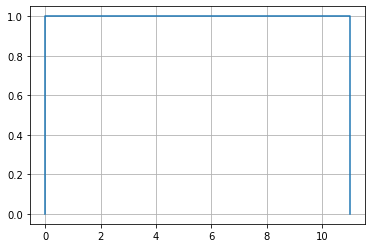

In [39]:
plt.plot(optimal_path_j, optimal_path_i)
plt.grid()
Q

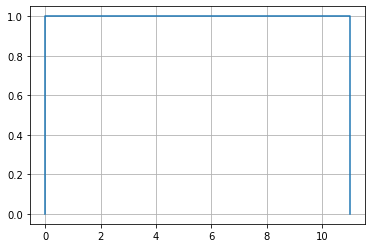

In [40]:
# From final Q[4x12x4] value (an estimated q*), find the path
path_i=[]
path_j=[]
i=0
j=0
path_i.append(i)
path_j.append(j)

while True:
    
    if i==0 and j==11:
        break;
    A=np.argmax(Q[i,j])
    if A==0:
        next_i=i
        temp_j=j+1
        if temp_j>11:
            next_j=11
        else:
            next_j=temp_j
                      
    elif A==1:
        temp_i=i+1
        if temp_i<=3:
            next_i=temp_i
        else:
            next_i=3
        next_j=j
             
            
    elif A==2:
        next_i=i
        temp_j=j-1
        if temp_j<0:
            next_j=0
        else:
            next_j=temp_j  
              
                
    elif A==3:
        temp_i=i-1
        if temp_i<0:
            next_i=0
        else:
            next_i=temp_i
        next_j=j
            
    if next_i==0 and (next_j<11 and next_j>0):
        next_i=0
        next_j=0  
    i=next_i
    j=next_j
    path_i.append(i)
    path_j.append(j)
     
plt.plot(path_j, path_i)
plt.grid()

In [10]:
Q

array([[[-112.9999208 ,  -13.        ,  -13.99995261,  -13.99999333],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ]],

       [[ -12.        ,  -13.70658374,  -12.99999853,  -13.99999956],
        [ -11.        ,  -12.742851  ,  -12.99987846, -112.99237061],
        [ -10.    

In [11]:
Q

array([[[-112.9999208 ,  -13.        ,  -13.99995261,  -13.99999333],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ],
        [   0.        ,    0.        ,    0.        ,    0.        ]],

       [[ -12.        ,  -13.70658374,  -12.99999853,  -13.99999956],
        [ -11.        ,  -12.742851  ,  -12.99987846, -112.99237061],
        [ -10.    